In [1]:
import numpy as np
from datasets import load_dataset
import sys
sys.path.append("../")
from cumulant_analyzer import CumulantAnalyzer, to_numpy
from transformers.utils.logging import disable_progress_bar
disable_progress_bar()
from plot_utils import plot_comparison_transposed

%matplotlib inline

In [2]:
analyzer = CumulantAnalyzer(model_name='gpt2-large', max_length = 256, verbose = False)

In [3]:
def choose_random_index_from_topic(input_topic):
    filered_topics = [item['pile_set_name'] for i, item in enumerate(ds['meta']) if i in filtered_indices]
    indices = [i for i, topic in enumerate(filered_topics) if topic == input_topic]
    return np.random.choice(indices)

In [4]:
ds = load_dataset("NeelNanda/pile-10k")['train']
filtered_indices = np.load('filtered_indices.npy')

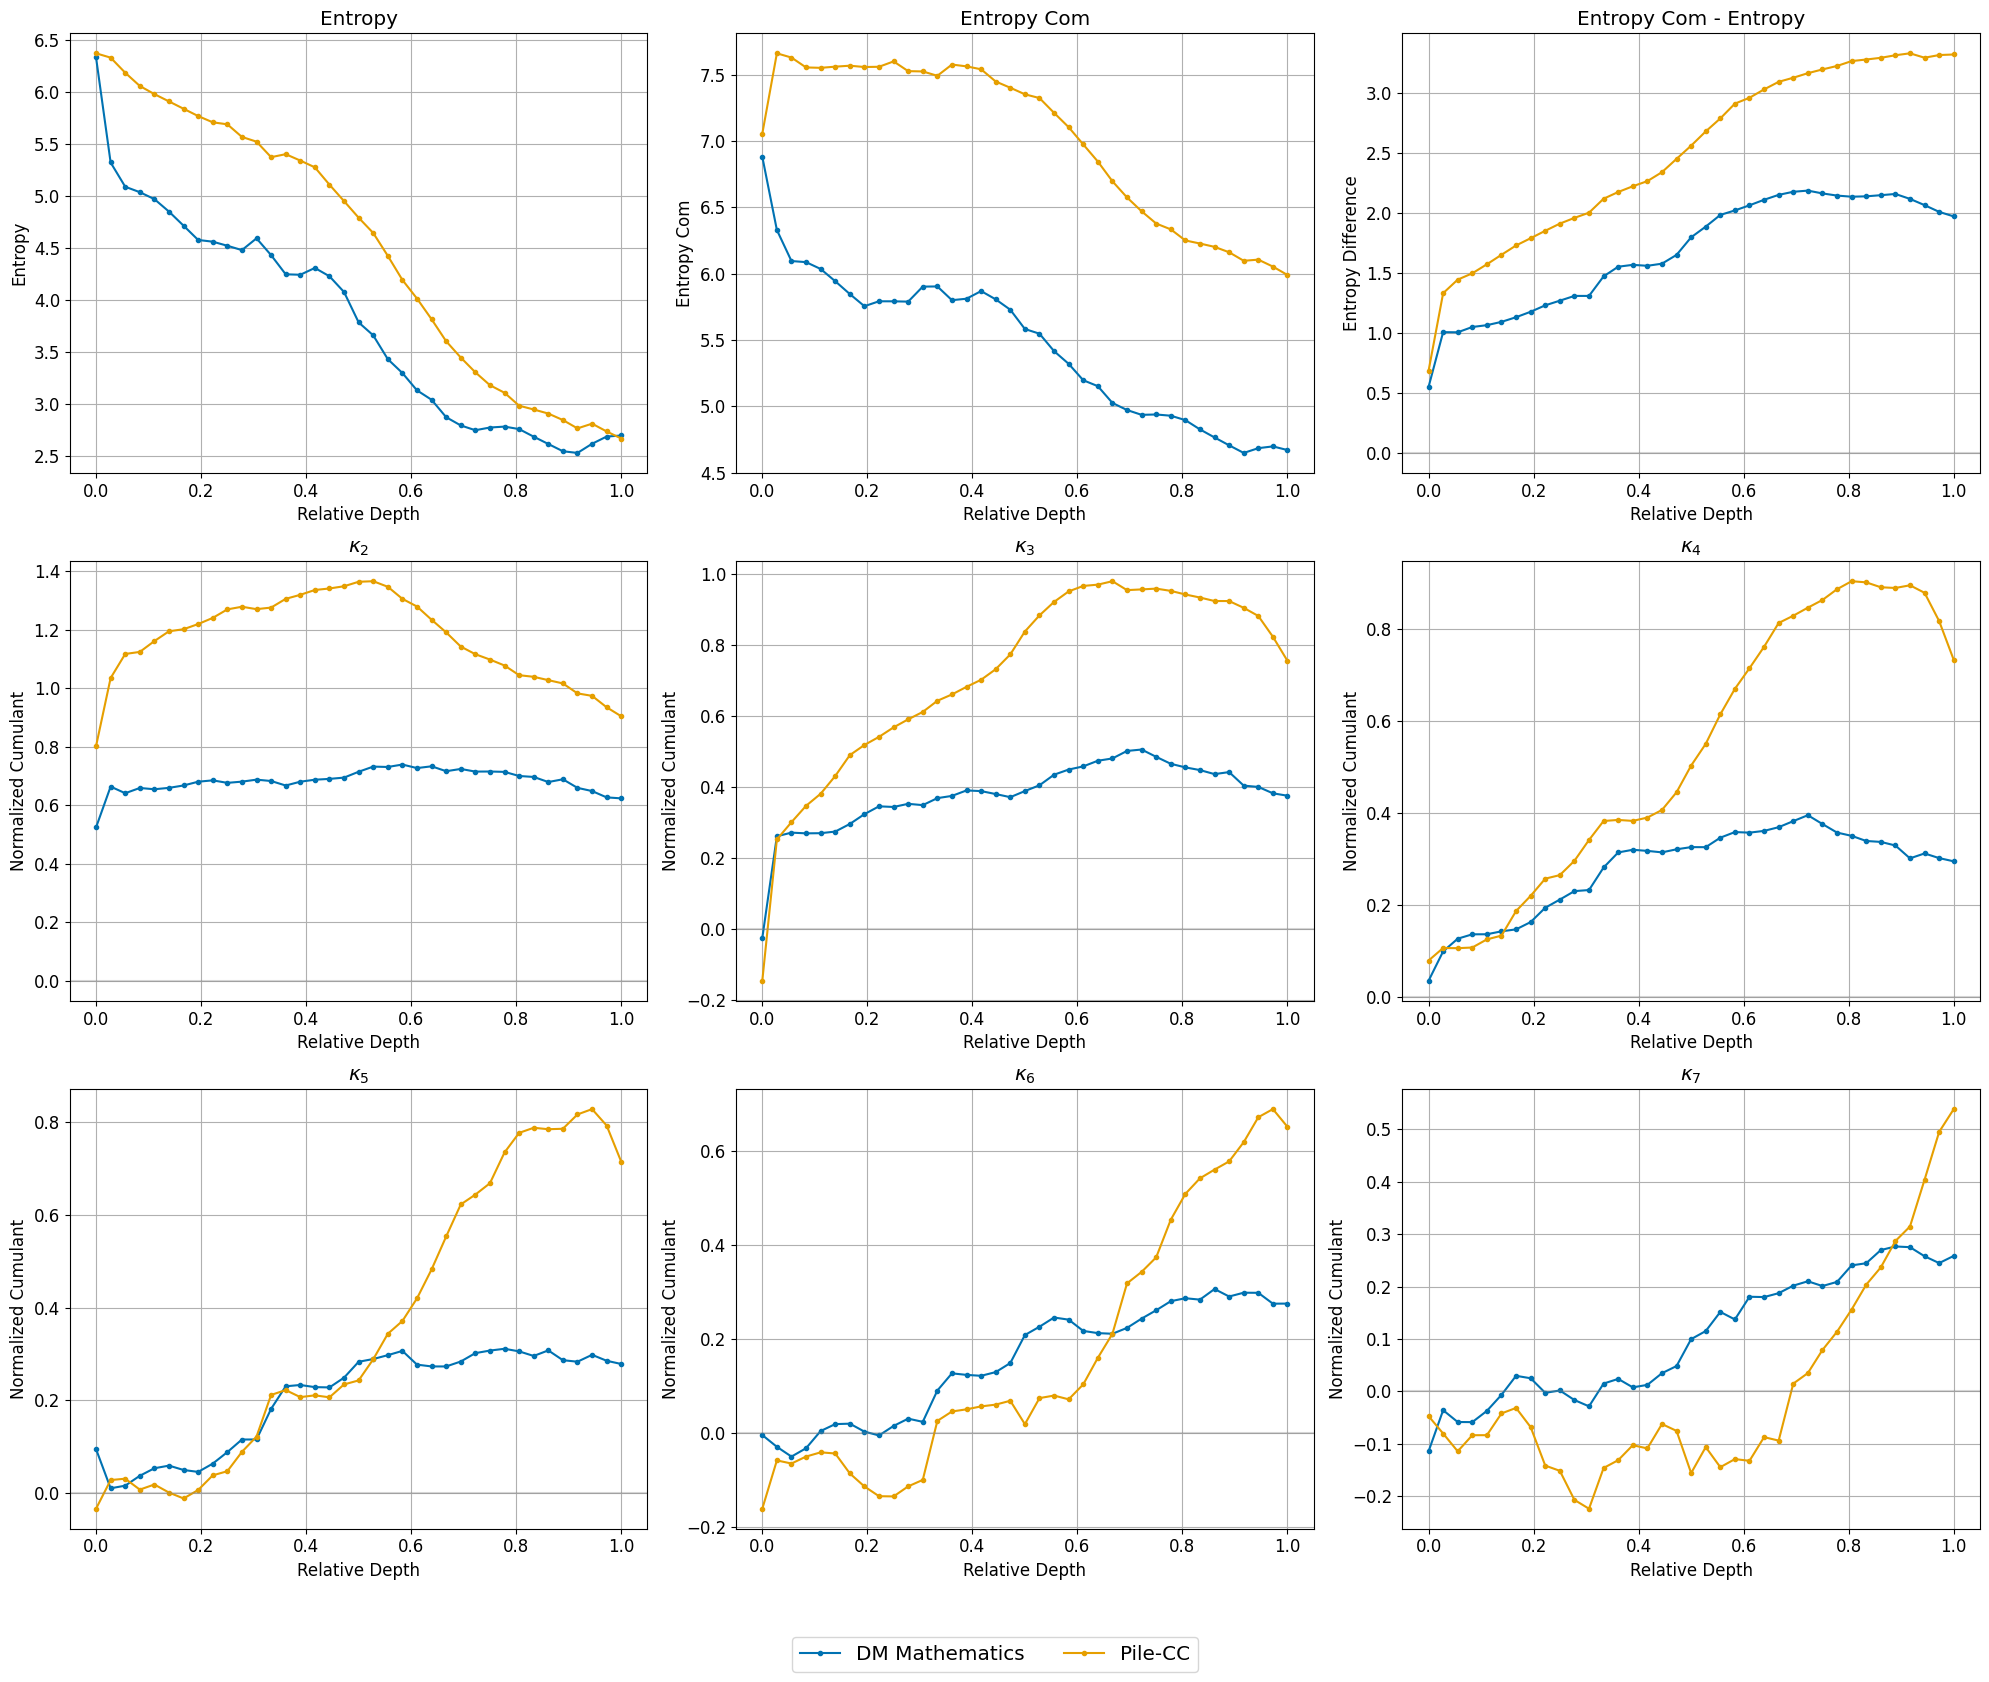

In [5]:
topic1 = "DM Mathematics"
index1 = choose_random_index_from_topic(topic1)
test_sequence = ds['text'][filtered_indices[index1]]
stats = analyzer.compute_stats(test_sequence)

topic2 = "Pile-CC"
index2 = choose_random_index_from_topic(topic2)
test_sequence = ds['text'][filtered_indices[index2]]
shuffled_stats = analyzer.compute_stats(test_sequence)

fig = plot_comparison_transposed(stats, shuffled_stats, [topic1, topic2])